<a href="https://colab.research.google.com/github/onietosi/deep-learning-with-python-notebooks/blob/master/5.3-using-a-pretrained-convnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 데이터셋 다운로드

* 다운로드 링크: [dogs-vs-cats 데이터셋](www.kaggle.com/c/dogs-vs-cats/data)
* 주요 데이터셋 path 설정을 위해 `15_1_using_convnets_with_small_datasets.ipynb`의 데이터셋 다운로드 부분을 다시 실행한다.
* 지난번 단계에서 생성된 `cats_and_dogs_small` 폴더 전체를 삭제하고 다음 셀을 실행한다.

In [1]:
import os, shutil

# 원래 데이터셋 중 train 폴더
original_dataset_dir = './dogs-vs-cats/train'

# 작은 데이터셋을 저장할 위치 : 앞으로 데이터셋의 시작 위치가 됨
base_dir = './dogs-vs-cats/cats_and_dogs_small'
os.mkdir(base_dir)

# training, validation 및 test 데이터셋을 분할 저장할 위치
train_dir = os.path.join(base_dir, 'train')
os.mkdir(train_dir)
validation_dir = os.path.join(base_dir, 'validation')
os.mkdir(validation_dir)
test_dir = os.path.join(base_dir, 'test')
os.mkdir(test_dir)

# cat 훈련 데이터
train_cats_dir = os.path.join(train_dir, 'cats')
os.mkdir(train_cats_dir)

# dog 훈련 데터터
train_dogs_dir = os.path.join(train_dir, 'dogs')
os.mkdir(train_dogs_dir)

# cat 검증 데이터
validation_cats_dir = os.path.join(validation_dir, 'cats')
os.mkdir(validation_cats_dir)

# dog 검증 데터터
validation_dogs_dir = os.path.join(validation_dir, 'dogs')
os.mkdir(validation_dogs_dir)

# cat 테스트 데이터
test_cats_dir = os.path.join(test_dir, 'cats')
os.mkdir(test_cats_dir)

# dog 테스트 데이터
test_dogs_dir = os.path.join(test_dir, 'dogs')
os.mkdir(test_dogs_dir)

# cat 이미지 중에서 처음 1,000개를 train_cats_dir로 copy
fnames = ['cat.{}.jpg'.format(i) for i in range(1000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(train_cats_dir, fname)
    shutil.copyfile(src, dst)

# 다음 500개의 cat 이미지를 validation_cats_dir로 copy
fnames = ['cat.{}.jpg'.format(i) for i in range(1000, 1500)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(validation_cats_dir, fname)
    shutil.copyfile(src, dst)

# 다음 500개의 cat 이미지를 test_cats_dir로 copy
fnames = ['cat.{}.jpg'.format(i) for i in range(1500, 2000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(test_cats_dir, fname)
    shutil.copyfile(src, dst)

# Copies the first 1,000 dog images to train_dogs_dir
# dog 이미지 중에서 처음 1,000개를 train_dogs_dir로 copy
fnames = ['dog.{}.jpg'.format(i) for i in range(1000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(train_dogs_dir, fname)
    shutil.copyfile(src, dst)

# 다음 500개의 dog 이미지를 validation_dogs_dir로 copy
fnames = ['dog.{}.jpg'.format(i) for i in range(1000, 1500)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(validation_dogs_dir, fname)
    shutil.copyfile(src, dst)

# Copies the next 500 dog images to test_dogs_dir
# 다음 500개의 d 이미지를 test_dogs_dir로 copy
fnames = ['dog.{}.jpg'.format(i) for i in range(1500, 2000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(test_dogs_dir, fname)
    shutil.copyfile(src, dst)

# Using a pre-trained convnet

[Note] 이 노트북은 [Deep Learning with Python](https://www.manning.com/books/deep-learning-with-python?a_aid=keras&a_bid=76564dff)의 제5장 2절의 내용을 일부 수정하여 작성한 것이다.

----
* 소규모 이미지 데이터셋에 대한 딥 러닝의 일반적이고 매우 효과적인 접근 방식은 사전 훈련된 네트워크를 활용하는 것이다.
* 사전 훈련된 네트워크는 일반적으로 대규모 이미지 분류 작업을 위해 대규모 데이터셋에서 사전에 훈련되어 저장된 네트워크를 말한다.
* 원본 데이터셋이 충분히 크고 일반적이라면, 사전 훈련된 네트워크에서 학습된 공간적 특징 계층 구조는 시각적 세계의 일반적인 모델 역할을 효과적으로 수행할 수 있으며, 따라서 그 특징은 (새로운 문제가 원래 작업의 클래스와 완전히 다른 클래스를 포함할 수 있더라도) 다양한 컴퓨터 비전 문제에 유용할 수 있다.
*  예를 들어, ImageNet(클래스가 대부분 동물과 일상 사물인 경우)에서 네트워크를 훈련한 다음, 이 훈련된 네트워크를 이미지에서 가구를 식별하는 것과 같은 원격 작업에 다시 사용할 수 있다.
*  학습된 특징의 이러한 다양한 문제 간 이식성은 기존의 많은 얕은 학습 접근 방식과 비교했을 때 딥 러닝의 주요 이점이며, 딥 러닝을 소규모 데이터 문제에 매우 효과적이게 만든다.

이 장에서는 ImageNet 데이터셋(레이블이 지정된 140만 개의 이미지와 1,000개의 서로 다른 클래스)을 기반으로 사전 학습된 대규모 convnet을 고려해 보겠다. ImageNet에는 다양한 종(種)의 고양이와 개를 포함한 많은 동물 클래스가 포함되어 있으므로, 고양이 대 개 분류 문제에서 매우 우수한 성능을 기대할 수 있다.

사전 훈련된 신경망 모델로는 2014년 Karen Simonyan과 Andrew Zisserman이 개발한 VGG16 아키텍처를 사용할 것이다. 이 아키텍처는 ImageNet에서 간단하고 널리 사용되는 convnet 아키텍처다. VGG16은 다소 오래된 모델이고 최신 기술과는 거리가 멀며 다른 최신 모델보다 다소 무겁지만, 이미 익숙한 아키텍처와 유사하고 새로운 개념을 도입하지 않고도 쉽게 이해할 수 있기 때문에 흔히 선택된다.

사전 학습된 네트워크를 활용하는 방법에는 **특징 추출**과 **미세 조정** 두 가지가 있다.

## 특징 추출(Feature extraction)

* 사전 학습된 신경망이 학습한 표현을 사용하여 새로운 샘플들로부터 흥미로운 특징들을 추출
* Convnet(또는 CNN)의 경우, 사전 학습된 신경망의 합성곱 기반convolutional base(합성곱 및 풀링 층 전체)을 고정시킨 채로 새로운 데이터를 통과시켜 나온 출력으로 새로운 분류기를 훈련시킨다.

![swapping FC classifiers](https://s3.amazonaws.com/book.keras.io/img/ch5/swapping_fc_classifier.png)

#### 합성곱 기반Convolution base만 재사용할까? 밀집Dense층으로 연결된 분류기를 재사용하면 안될까?
* 대부분 쓸모 없다.
* 분류기가 학습한 표현은 모델이 학습된 클래스 집합에 매우 구체적이다.
* 즉, 전체 그림에서 특정 클래스의 존재 확률에 대한 정보만 포함한다.
* 또한, 밀집 연결층에서 발견된 표현은 입력 이미지에서 객체의 위치에 대한 정보를 더 이상 포함하지 않는다.
* 그러나, 현재 문제의 클래스들과 유사하고 내용이 비슷하거나 포함된다면 재사용 가능하다.

#### 표현Representation의 재사용성(또는 일반성 수준)
* 모델의 층의 깊이에 따라 달라진다.
* 초기층은 지역적이며, 모서리, 색, 질감 같은 지극히 일반적인 특징generic features을 추출한다.
* 깊은층은 더 추상적인 개념(예: 고양이의 귀, 개의 눈 등)을 추출
* 상황이 많이 다르다면 합성곱 기반의 처음 몇 층만 재사용하는 것이 바람직하다.


#### 우리의 계획
* ImageNet으로 학습된 VGG16 합성곱 기반을 사용하여 고양이와 개 이미지에서 흥미로운 특징을 추출하고, 이 특징을 기반으로 고양이 vs. 개 분류기를 학습시켜 실제로 구현해보자.

### 재현성을 위한 random seed 설정

In [2]:
import os
import numpy as np
import tensorflow as tf
import random

# 텐서플로우를 포함한 모델을 실행할 때마다 동일한 결과를 얻기 위한 재현성 설정 함수.
# 같은 코드로 여러 모델을 만드는 경우 각 모델이 만들어지기 전에 다시 실행해야 함.
def set_random_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = "1"
    os.environ['TF_CUDNN_DETERMINISM'] = "1"  # 최신 TF에서는 위의 것으로 대체 가능
    os.environ['PYTHONHASHSEED'] = str(seed)

set_random_seed(seed=42)

VGG16 model을 인스턴스화한다:

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16

conv_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150, 150, 3))

* `weights`: 모델을 초기화시킬 가중치 checkpoint를 지정
* `include_top`: 네트워크 상단에 밀집 연결된 분류기를 포함할지 여부를 나타냄. 기본적으로 이 밀집 연결 분류기는 ImageNet의 1,000개 클래스에 대응한다. 우리는 고양이와 개, 두 클래스만 사용하는 자체 밀집 연결 분류기를 사용할 예정이므로, 이를 포함할 필요가 없다.
* `input_shape`: 네트워크에 입력시킬 이미지 텐서의 shape. 이 인수는 선택적이다(넘겨주지 않으면 네트워크는 임의의 크기의 입력을 처리할 수 있다).

In [4]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 150, 150, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 150, 150, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 75, 75, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 75, 75, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 75, 75, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 37, 37, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 37, 37, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 37, 37, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 37, 37, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 18, 18, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 18, 18, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 9, 9, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

최종 특징 맵의 shape=(4, 4, 512) 이다. 특징 맵 위에 밀집 연결 분류기를 붙일 것이다.

### 특징 추출 수행 방법 2 가지:

**방법 1**: Fast feature extraction without data augmentation
* 현재 데이터셋으로 convolutional base를 실행
* 출력을 Numpy array로 디스크에 저장
* 저장된 출력을 별도의 densely connected classifier의 입력으로 사용하여 훈련
* 가장 경제적이고 쉬운 방법이지만 data augmentation이 배제됨

**방법 2**: Feature extraction with data augmentation
* Convolutional base 위에 Dense layer를 추가
* 새로운 전체 모델을 현재 데이터셋으로 end-to-end 훈련 (단, Convolutional base를 freeze)
* data augmentation 사용 가능
* 첫번째 방법 1보다 비용이 많이 든다.

In [5]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)
batch_size = 20

def extract_features(directory, sample_count):
    features = np.zeros(shape=(sample_count, 4, 4, 512))
    labels = np.zeros(shape=(sample_count))
    generator = datagen.flow_from_directory(
        directory,
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')
    i = 0
    for inputs_batch, labels_batch in generator:
        features_batch = conv_base.predict(inputs_batch)
        features[i * batch_size : (i + 1) * batch_size] = features_batch
        labels[i * batch_size : (i + 1) * batch_size] = labels_batch
        i += 1
        if i * batch_size >= sample_count:
            break   # 뱃치가 무한히 생성되므로, 적정 조건에서 정지시켜야 한다.
    return features, labels

train_features, train_labels = extract_features(train_dir, 2000)
validation_features, validation_labels = extract_features(validation_dir, 1000)
test_features, test_labels = extract_features(test_dir, 1000)

Found 2000 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━

* 추출된 특징의 shape=`(samples, 4, 4, 512)`
* 이것을 밀집 연결된 분류기에 입력할 것이므로, 먼저 `(samples, 8192)` 크기로 평탄화시켜야 한다:

In [6]:
train_features = np.reshape(train_features, (2000, 4 * 4 * 512))
validation_features = np.reshape(validation_features, (1000, 4 * 4 * 512))
test_features = np.reshape(test_features, (1000, 4 * 4 * 512))

이 시점에서 밀집 연결 분류기를 정의할 수 있으며(dropout 규제를 주목할 것), 방금 기록한 데이터와 레이블에서 훈련할 수 있다:

In [7]:
from tensorflow.keras import layers, models, optimizers

model = models.Sequential()
model.add(layers.Dense(256, activation='relu', input_dim=4 * 4 * 512))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer=optimizers.RMSprop(learning_rate=2e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_features, train_labels,
                    epochs=30,
                    batch_size=20,
                    validation_data=(validation_features, validation_labels))

Epoch 1/30


C:\Users\kikim\anaconda3\envs\handson3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6061 - loss: 0.6782 - val_accuracy: 0.8640 - val_loss: 0.4219
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8075 - loss: 0.4289 - val_accuracy: 0.8840 - val_loss: 0.3439
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8530 - loss: 0.3598 - val_accuracy: 0.8850 - val_loss: 0.3116
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8560 - loss: 0.3216 - val_accuracy: 0.8890 - val_loss: 0.2904
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8858 - loss: 0.2810 - val_accuracy: 0.8950 - val_loss: 0.2747
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8977 - loss: 0.2523 - val_accuracy: 0.8960 - val_loss: 0.2671
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9028 - loss: 0.2466 - val_accuracy: 0.8950 - val_loss: 0.2604
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9031 - loss: 0.2310 - val_accuracy: 0.8970 - val_

* 두 개의 밀집층만 처리하므로 훈련 속도가 빠르다 -- CPU만으로 훈련해도 1 에포크에 1초 미만이다.
* 이제 훈련과정에서의 손실함수와 정확도 그래프를 살펴보자:

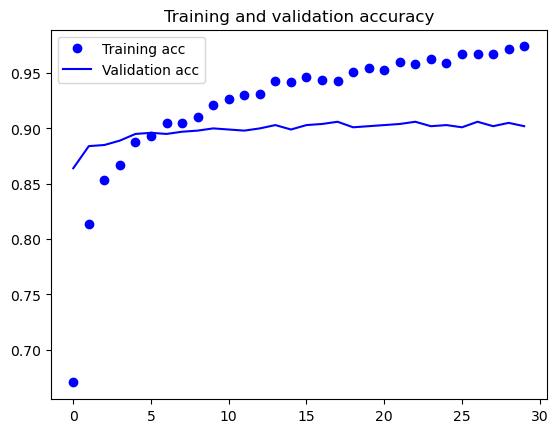

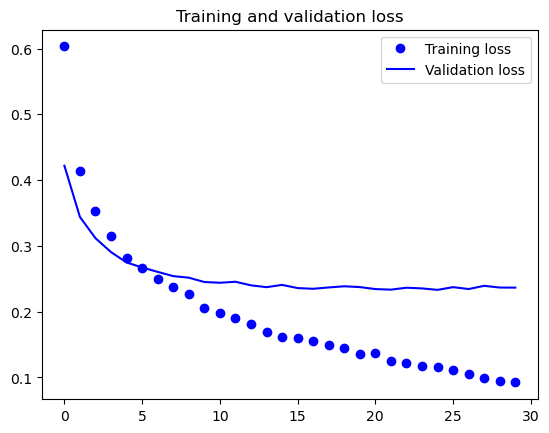

In [8]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']


loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

* 앞 장에서 처음부터 학습된 작은 모델로 달성할 수 있었던 것보다 훨씬 높은 약 90%의 검증 정확도를 달성했다.
* 그러나, 상당히 높은 비율의 드롭아웃을 사용했음에도 불구하고 그래프를 보면 거의 처음부터 과적합이 발생하고 있음을 알 수 있다.
* 이것은 이 기법이 작은 이미지 데이터 세트에서 과적합을 방지하는 데 필수적인 데이터 증강을 활용하지 않기 때문이다.

이제 훨씬 느리고 비용이 많이 들지만, 학습 중에 데이터 증강을 활용할 수 있는 두 번째 기법인 `conv_base` 모델을 확장하여 입력에 대해 종단 간(end-to-end)으로 실행하는 특징 추출 기법을 살펴보자. 이 기법은 실제로 비용이 매우 많이 들기 때문에 GPU를 사용할 수 있는 경우에만 시도해야 한다. CPU에서는 완전히 다루기 어렵다. GPU에서 코드를 실행할 수 없다면 이전 기법을 사용하는 것이 좋다.

* 모델은 레이어처럼 동작하므로 레이어를 추가하는 것처럼 `Sequential` 모델에 모델(예: `conv_base`)을 추가할 수 있다.
* 그러므로 다음과 같은 작업을 수행할 수 있다:

In [9]:
from tensorflow.keras import layers, models

model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

* 보다시피 VGG16의 합성곱 기반은 14,714,688개의 파라미터를 가지는데, 이는 매우 큰 값이다. 위에 추가하는 분류기는 2백만 개의 파라미터를 갖는다.
* 모델을 컴파일하고 학습시키기 전에 매우 중요한 작업은 합성곱 기반을 고정(freeze)하는 것이다.
* 층(layer) 또는 층 집합(set of layers)을 "고정"한다는 것은 학습 중에 가중치가 업데이트되지 않도록 하는 것을 의미한다. 이렇게 하지 않으면
이전에 합성곱 기반에서 학습한 표현이 학습 중에 수정된다.
* 위의 `Dense` 계층은 무작위로 초기화되므로 매우 큰 가중치 업데이트가 네트워크 전체에 전파되어 이전에 학습된 표현을 사실상 파괴한다.
* 케라스에서 네트워크를 고정하려면 `trainable` 속성을 `False`로 설정한다.

In [11]:
print('This is the number of trainable weights '
      'before freezing the conv base:', len(model.trainable_weights))

This is the number of trainable weights before freezing the conv base: 30


In [12]:
conv_base.trainable = False

In [13]:
print('This is the number of trainable weights '
      'after freezing the conv base:', len(model.trainable_weights))

This is the number of trainable weights after freezing the conv base: 4


* 이 설정을 사용하면 추가한 두 개의 `Dense` 레이어의 가중치만 학습된다. 즉, 층당 두 개씩, 총 네 개의 가중치 텐서가 있다(메인 가중치 행렬과 편향 벡터). 
* 이러한 변경 사항을 적용하려면 먼저 모델을 컴파일해야 한다.
* 컴파일 후 가중치 학습 가능성을 수정하는 경우 모델을 다시 컴파일해야 한다. 그렇지 않으면 변경 사항이 무시된다.

이제 이전 예제에서 사용한 것과 동일한 데이터 증강 구성을 사용하여 모델 학습을 시작할 수 있다:

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

# [주의!] 검증 데이터는 증강하면 안된다!
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        train_dir,               # 타겟 디렉터리
        target_size=(150, 150),  # 모든 이미지는 150x150 크기로 조정됨
        batch_size=20,
        class_mode='binary')     # binary_crossentropy loss를 사용하므로 이진 레이블이 필요

validation_generator = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=2e-5),
              metrics=['accuracy'])

history = model.fit(
      train_generator,
      steps_per_epoch=100,
      epochs=30,
      validation_data=validation_generator,
      validation_steps=50,
      verbose=2)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Epoch 1/30


C:\Users\kikim\anaconda3\envs\handson3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 - 50s - 500ms/step - accuracy: 0.6850 - loss: 0.6011 - val_accuracy: 0.8200 - val_loss: 0.4602
Epoch 2/30
100/100 - 49s - 494ms/step - accuracy: 0.7920 - loss: 0.4817 - val_accuracy: 0.8380 - val_loss: 0.3919
Epoch 3/30
100/100 - 49s - 495ms/step - accuracy: 0.8070 - loss: 0.4376 - val_accuracy: 0.8510 - val_loss: 0.3451
Epoch 4/30
100/100 - 50s - 502ms/step - accuracy: 0.8295 - loss: 0.4046 - val_accuracy: 0.8530 - val_loss: 0.3359
Epoch 5/30
100/100 - 51s - 511ms/step - accuracy: 0.8320 - loss: 0.3937 - val_accuracy: 0.8760 - val_loss: 0.2989
Epoch 6/30
100/100 - 50s - 496ms/step - accuracy: 0.8420 - loss: 0.3756 - val_accuracy: 0.8770 - val_loss: 0.2894
Epoch 7/30
100/100 - 49s - 495ms/step - accuracy: 0.8485 - loss: 0.3504 - val_accuracy: 0.8790 - val_loss: 0.2840
Epoch 8/30
100/100 - 50s - 498ms/step - accuracy: 0.8395 - loss: 0.3582 - val_accuracy: 0.8830 - val_loss: 0.2752
Epoch 9/30
100/100 - 50s - 495ms/step - accuracy: 0.8505 - loss: 0.3505 - val_accuracy: 0.8860 - va

In [15]:
model.save('cats_and_dogs_small_3.keras')

손실함수 및 정확도 그래프:

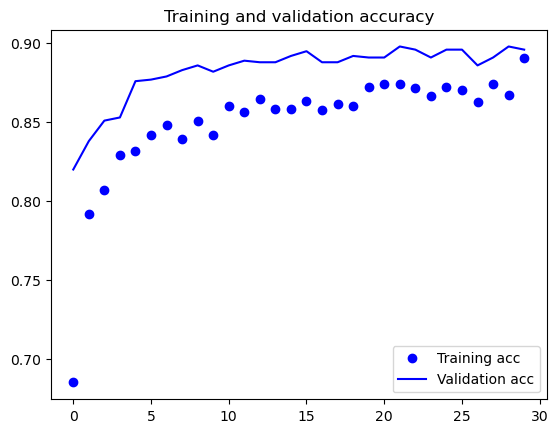

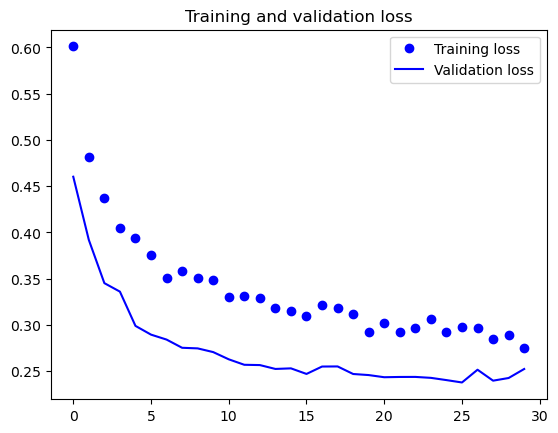

In [16]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

* 검증 정확도 약 90%로 데이터 증강이 없는 방법 1과 다를 것이 없어 보인다.
* 이것은 데이터 증강에 따른 효과가 거의 없었다는 것을 의미한다. 
* 증강된 이미지와 원래 이미지 사이의 강한 상관관계로 인해 추가된 분류기의 학습이 잘 되지 않기 때문

## 미세 조정(Fine-tuning)
* 특징 추출에 사용된 고정된 모델 기반(합성곱 기반)의 상위 계층 몇 개를 고정 해제하고, 새로 추가된 모델 부분(이 경우 완전 연결 분류기)과 이 상위 계층을 함께 훈련하는 것
* 미세 조정 시 학습률을 작게해야 하는 데, 이것은 기존에 학습된 유용한 가중치를 급격하게 변경하는 것을 방지하고, 새로운 데이터에 점진적으로 적응시키기 위한 것이다.

![fine-tuning VGG16](https://s3.amazonaws.com/book.keras.io/img/ch5/vgg16_fine_tuning.png)

* VGG16의 합성곱 기반을 동결해야 상위에 추가된 완전 연결 분류기를 훈련시킬 수 있듯이, 합성곱 기반 내 상위 계층을 미세 조정하는 것은 그 보다 상위의 완전 연결 분류기가 훈련된 이후에만 가능하다.
* 그러지 않으면, 훈련 중 네트워크를 통해 전파되는 오차 신호가 너무 커져 미세 조정 대상 계층에서 이전에 학습한 표현이 손상될 수 있다.

**미세 조정 단계:**  
1) 사전 훈련된 신경망 기반(여기서는 합성곱 기반) 위에 사용자 지정 신경망을 추가한다.
2) 신경망 기반을 동결한다.
3) 추가한 부분을 훈련한다.
4) 신경망 기반의 일부 계층 동결을 해제한다.
5) 동결 해제된 계층과 추가한 부분을 함께 훈련한다.

* 앞에서 1 단계부터 3 단계까지는 이미 완료.

#### 4 단계: conv_base를 동결 해제한 다음, 그 안에 있는 개별 계층을 동결한다.

현재 우리 모델의 합성곱 기반의 구조:

In [17]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 150, 150, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 150, 150, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 75, 75, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 75, 75, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 75, 75, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 37, 37, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 37, 37, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 37, 37, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 37, 37, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 18, 18, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 18, 18, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 9, 9, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

* 미세 조정 대상: 마지막 3개 합성곱 층(`block5_conv1`, `block5_conv2`, `block5_conv3`)
* 더 많은 계층을 미세 조정하는 것은 어떨까? 또는 전체 합성곱 기반을 미세 조정하는 것은 어떨까? 물론 가능하지만 다음 사항을 고려해야 한다:
  * 합성곱 기반 계층의 앞부분 계층은 더 일반적이고 재사용 가능한 특성을 인코딩하는 반면, 위쪽 계층은 더 특화된 특성을 인코딩한다.
  * 새로운 문제에서 이러한 특성을 재활용해야 하므로, 더 특화된 특성을 미세 조정하는 것이 더 유용하다.
  * 아래쪽 계층을 미세 조정하면 성능이 빠르게 저하된다.
  * 학습하는 파라미터 수가 많을수록 과적합 위험이 커진다. 합성곱 기반 계층은 1,500만 개의 매개변수를 가지고 있으므로, 작은 데이터셋에서 훈련을 시도하는 것은 위험하다.
  * 따라서 이 상황에서는 합성곱 기반 레이어의 상위 2~3개 층만 미세 조정하는 것이 좋은 전략이다.

이전 예제에서 중단했던 부분부터 시작하여 설정해 보자:

In [18]:
conv_base.trainable = True

set_trainable = False
for layer in conv_base.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

* 이제 신경망 미세 조정을 시작할 수 있다.
* RMSprop 옵티마이저를 사용하고 매우 낮은 학습률을 사용한다.
* 낮은 학습률을 사용하는 이유는 미세 조정하는 3개 층의 표현에 대한 수정의 크기를 제한하기 위해서다. 너무 큰 업데이트는 사전 훈련된 표현을 파괴할 수 있다.

이제 미세 조정을 시작한다.

In [19]:
set_random_seed(seed=42)

In [20]:
model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-5),
              metrics=['accuracy'])

history = model.fit(
      train_generator,
      steps_per_epoch=100,
      epochs=100,
      validation_data=validation_generator,
      validation_steps=50)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 544ms/step - accuracy: 0.8670 - loss: 0.3216 - val_accuracy: 0.8950 - val_loss: 0.2377
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 543ms/step - accuracy: 0.8836 - loss: 0.2562 - val_accuracy: 0.8930 - val_loss: 0.2617
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 543ms/step - accuracy: 0.9107 - loss: 0.2249 - val_accuracy: 0.9080 - val_loss: 0.2222
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 542ms/step - accuracy: 0.9032 - loss: 0.2166 - val_accuracy: 0.9170 - val_loss: 0.1860
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 542ms/step - accuracy: 0.9190 - loss: 0.1991 - val_accuracy: 0.9250 - val_loss: 0.1857
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 543ms/step - accuracy: 0.9160 - loss: 0.1925 - val_accuracy: 0.9280 - val_loss: 0.1813
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 542ms/step - accuracy: 0.9227 - loss: 0.1722 - val_accuracy: 0.9230 - val_loss: 0.1788
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 544ms/step - accuracy: 0.9315 -

In [21]:
model.save('cats_and_dogs_small_4.keras')

손실함수 및 정확도 그래프

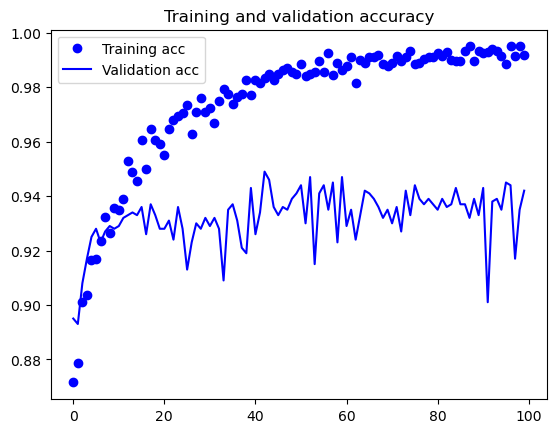

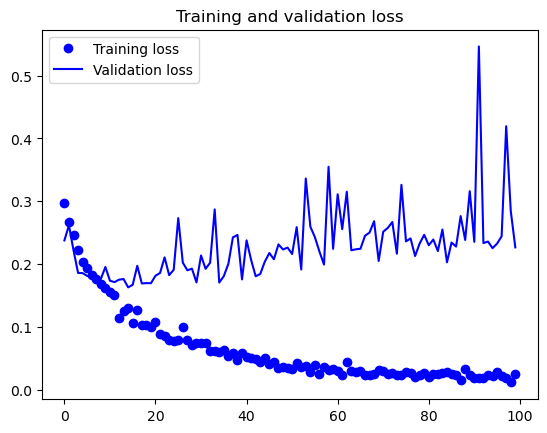

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

지수 이동 평균을 사용하여 손실과 정확도 그래프를 매끄럽게 만들 수 있다

In [23]:
def smooth_curve(points, factor=0.8):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

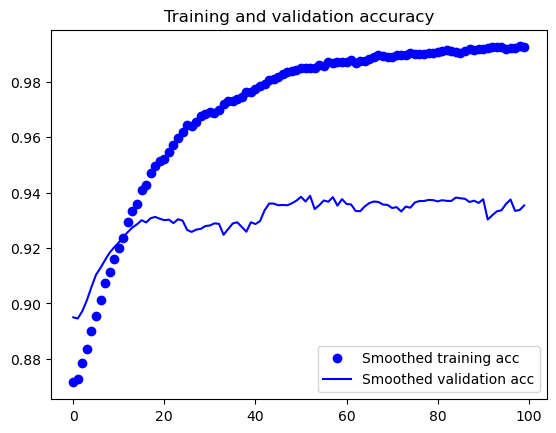

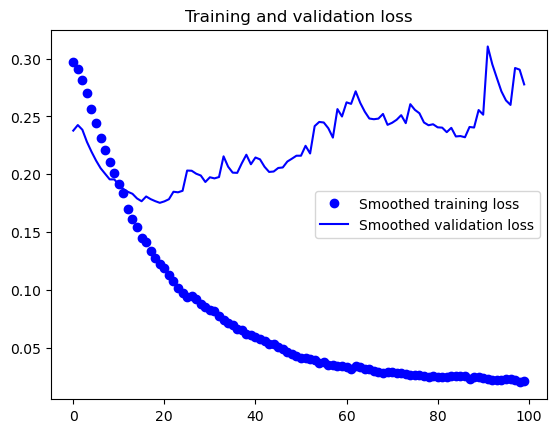

In [24]:
plt.plot(epochs, smooth_curve(acc), 'bo', label='Smoothed training acc')
plt.plot(epochs, smooth_curve(val_acc), 'b', label='Smoothed validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, smooth_curve(loss), 'bo', label='Smoothed training loss')
plt.plot(epochs, smooth_curve(val_loss), 'b', label='Smoothed validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

* 이 곡선들은 훨씬 더 깔끔하고 안정적으로 보인다. 
* 약 3%의 절대적인 성능 개선을 보이고 있다.
* 그런데 손실 곡선은 실질적인 개선을 보이지 않고 오히려 악화되고 있다.
* 손실이 감소하지 않는데 어떻게 정확도는 향상될 수 있을까?
  - 개선 이전에 “개: 45%, 고양이: 55%”로 고양이(정답: 개)라고 틀린 예측을 하는 상태였다고 하자.
  - 이 때는 정확도는 낮고 손실은 높은 상태이다.
  - 개선 이후에 “개:51%, 고양이:49%”로 예측했다면 차이는 적으나 개가 우세하므로 개라고 예측하게 된다.
  - 그러면 정확도는 높아지지만 개에 대한 예측 확률이 낮아서 손실은 여전히 높은 상태가 된다.

이제 마침내 테스트 데이터에서 이 모델을 평가할 수 있다.

In [25]:
test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')

test_loss, test_acc = model.evaluate(test_generator, steps=50)
print('test acc:', test_acc)

Found 1000 images belonging to 2 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 309ms/step - accuracy: 0.9379 - loss: 0.2539
test acc: 0.9369999766349792


여기서 93.8%의 테스트 정확도를 얻었다. 사용 가능한 데이터의 약 10%(2,000 개)의 샘플로 상당히 좋은 결과를 얻었다. 20,000개의 샘플을 사용하는 것과는 엄청난 차이가 있다.